# Convolutional Neural Network (CNN) for Time Series Classification

## Notebook Overview

This notebook demonstrates the process of building, training, and evaluating a Convolutional Neural Network (CNN) for a time series classification task using PyTorch. The goal is to classify sequences of data into one of 11 possible classes. The notebook explores several training configurations, varying learning rates, optimizers, and batch normalization to identify the best performing model.

### Contents:

1.  **Data Loading and Preparation**: Loading a `.npz` dataset, creating custom PyTorch `Dataset` and `DataLoader` instances, and splitting data into training, validation, and test sets.
2.  **Helper Functions**: Essential utility functions for reproducibility, accuracy computation, confusion matrix generation, and plotting training metrics.
3.  **Model Definition**: Definition of the CNN architecture, including convolutional layers, activation functions, pooling layers, and a classifier head.
4.  **Model Training Experiments**: A series of experiments (`Step 1` through `Step 5`) with different hyperparameter configurations (learning rate, optimizer, batch size) and architectural modifications (e.g., adding BatchNorm) to observe their impact on model performance.
5.  **Results Analysis**: Visualization of training loss and accuracy curves for each experiment, along with a summary of the final train, validation, and test accuracies.
6.  **Model Saving**: Saving the best-performing model for future use.

# **Loading the Data**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import torch

In [ ]:
import torch.nn as nn
from torch.utils.data import Dataset

In [ ]:
project_data = np.load("/content/project_data.npz", allow_pickle=True)

X_train_np = project_data['X_train']
y_train_np = project_data['y_train']
X_test_np = project_data['X_test']
y_test_np = project_data['y_test']

The dataset is loaded from a `.npz` file, which typically contains NumPy arrays. It's then separated into training and testing features (`X_train`, `X_test`) and their corresponding labels (`y_train`, `y_test`). The `allow_pickle=True` argument is used in `np.load` to handle potentially pickled Python objects within the `.npz` file, which can be necessary for complex data structures.

In [ ]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cpu


## Custom Dataset Class

To efficiently load and preprocess data for PyTorch models, a custom `Dataset` class is defined. This class inherits from `torch.utils.data.Dataset` and is responsible for handling data loading, transformations, and returning individual samples. The `__init__` method converts the NumPy arrays to PyTorch tensors and moves them to the specified `DEVICE` (CPU or GPU). The `__len__` method returns the total number of samples, and `__getitem__` retrieves a sample (features and label) by its index.

In [ ]:
class My_Dataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    self.y = torch.tensor(y, dtype=torch.long).to(DEVICE)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [ ]:
train_dataset = My_Dataset(X_train_np, y_train_np)
test_dataset = My_Dataset(X_test_np, y_test_np)

In [ ]:
print(len(train_dataset))
print(len(test_dataset))

40500
4500


# **DataLoaders**

In [ ]:
from torch.utils.data import DataLoader

validation = int(0.1 * len(train_dataset))
train_dataset, validation_dataset = torch.utils.data.random_split(train_dataset, [len(train_dataset) - validation, validation])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
valid_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False)

## DataLoaders

`DataLoader` objects are used to iterate over datasets in mini-batches, providing features like shuffling, batching, and parallel data loading. Here, the `train_dataset` is further split into training and validation sets to monitor model performance during training and prevent overfitting. Separate `DataLoader` instances are then created for the training, validation, and test sets with a specified `batch_size`.

In [ ]:
print(len(train_loader))
print(len(valid_loader))
print(len(test_loader))

1140
127
141


In [ ]:
len(train_loader.dataset)

36450

## Helper Functions

This section defines several utility functions crucial for the machine learning workflow:

*   `set_all_seeds`: Ensures reproducibility by setting random seeds for `os`, `random`, `numpy`, and `torch`.
*   `set_deterministic`: Configures PyTorch for deterministic operations, which can be helpful for debugging and reproducibility, though it might impact performance.
*   `compute_accuracy`: Calculates the classification accuracy of a model on a given dataset, comparing predicted labels with true labels.
*   `compute_confusion_matrix`: Generates a confusion matrix to evaluate the performance of a classification model, providing insights into correct and incorrect predictions for each class.
*   `train_model`: The core training loop function that iterates over epochs, performs forward and backward passes, updates model parameters using an optimizer, and logs training progress (loss, train/validation accuracy). It also includes an optional scheduler for dynamic learning rate adjustments and prints the total training time and final test accuracy.
*   `plot_training_loss`: Visualizes the minibatch loss over iterations and epochs, with an option for a running average to smooth the curve.
*   `plot_accuracy`: Plots the training and validation accuracy over epochs to assess model performance and identify overfitting or underfitting.
*   `show_examples`: Displays a grid of sample predictions alongside true labels, optionally applying an unnormalizer for better visualization.
*   `plot_confusion_matrix`: Visualizes the confusion matrix with options for absolute counts, normalized values, and custom class names for better interpretability.

# **Helper Functions**

In [ ]:
import os
import numpy as np
import random
import torch
from distutils.version import LooseVersion as Version
from itertools import product


def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def set_deterministic():
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

    if torch.__version__ <= Version("1.7"):
        torch.set_deterministic(True)
    else:
        torch.use_deterministic_algorithms(True)


def compute_accuracy(model, data_loader, device):

    with torch.no_grad():

        correct_pred, num_examples = 0, 0

        for i, (features, targets) in enumerate(data_loader):

            features = features.to(device)
            targets = targets.float().to(device)

            logits = model(features)
            _, predicted_labels = torch.max(logits, 1)

            num_examples += targets.size(0)
            correct_pred += (predicted_labels == targets).sum()
    return correct_pred.float()/num_examples * 100


def compute_confusion_matrix(model, data_loader, device):

    all_targets, all_predictions = [], []
    with torch.no_grad():

        for i, (features, targets) in enumerate(data_loader):

            features = features.to(device)
            targets = targets
            logits = model(features)
            _, predicted_labels = torch.max(logits, 1)
            all_targets.extend(targets.to('cpu'))
            all_predictions.extend(predicted_labels.to('cpu'))

    all_predictions = all_predictions
    all_predictions = np.array(all_predictions)
    all_targets = np.array(all_targets)

    class_labels = np.unique(np.concatenate((all_targets, all_predictions)))
    if class_labels.shape[0] == 1:
        if class_labels[0] != 0:
            class_labels = np.array([0, class_labels[0]])
        else:
            class_labels = np.array([class_labels[0], 1])
    n_labels = class_labels.shape[0]
    lst = []
    z = list(zip(all_targets, all_predictions))
    for combi in product(class_labels, repeat=2):
        lst.append(z.count(combi))
    mat = np.asarray(lst)[:, None].reshape(n_labels, n_labels)
    return mat

In [ ]:
import time
import torch

def train_model(model, num_epochs, train_loader,
                valid_loader, test_loader, optimizer,
                device, logging_interval=50,
                scheduler=None,
                scheduler_on='valid_acc'):

    start_time = time.time()
    minibatch_loss_list, train_acc_list, valid_acc_list = [], [], []

    for epoch in range(num_epochs):
        # print("Length for epoch: ",epoch," = ",len(train_loader))
        model.train()
        for batch_idx, (features, targets) in enumerate(train_loader):

            features = features.to(device)
            targets = targets.to(device)

            # ## FORWARD AND BACK PROP
            logits = model(features)
            loss = torch.nn.functional.cross_entropy(logits, targets)
            optimizer.zero_grad()

            loss.backward()

            # ## UPDATE MODEL PARAMETERS
            optimizer.step()

            # ## LOGGING
            minibatch_loss_list.append(loss.item())
            if not batch_idx % logging_interval:
                print(f'Epoch: {epoch+1:03d}/{num_epochs:03d} '
                      f'| Batch {batch_idx:04d}/{len(train_loader):04d} '
                      f'| Loss: {loss:.4f}')

        model.eval()
        with torch.no_grad():  # save memory during inference
            train_acc = compute_accuracy(model, train_loader, device=device)
            valid_acc = compute_accuracy(model, valid_loader, device=device)
            print(f'Epoch: {epoch+1:03d}/{num_epochs:03d} '
                  f'| Train: {train_acc :.2f}% '
                  f'| Validation: {valid_acc :.2f}%')
            train_acc_list.append(train_acc.item())
            valid_acc_list.append(valid_acc.item())

        elapsed = (time.time() - start_time)/60
        print(f'Time elapsed: {elapsed:.2f} min')

        if scheduler is not None:

            if scheduler_on == 'valid_acc':
                scheduler.step(valid_acc_list[-1])
            elif scheduler_on == 'minibatch_loss':
                scheduler.step(minibatch_loss_list[-1])
            else:
                raise ValueError(f'Invalid `scheduler_on` choice.')


    elapsed = (time.time() - start_time)/60
    print(f'Total Training Time: {elapsed:.2f} min')

    test_acc = compute_accuracy(model, test_loader, device=device)
    print(f'Test accuracy {test_acc :.2f}%')

    return minibatch_loss_list, train_acc_list, valid_acc_list


In [ ]:
# imports from installed libraries
import os
import matplotlib.pyplot as plt
import numpy as np
import torch


def plot_training_loss(minibatch_loss_list, num_epochs, iter_per_epoch,
                       results_dir=None, averaging_iterations=100):

    plt.figure()
    ax1 = plt.subplot(1, 1, 1)
    ax1.plot(range(len(minibatch_loss_list)),
             (minibatch_loss_list), label='Minibatch Loss')

    if len(minibatch_loss_list) > 1000:
        ax1.set_ylim([
            0, np.max(minibatch_loss_list[1000:])*1.5
            ])
    ax1.set_xlabel('Iterations')
    ax1.set_ylabel('Loss')

    ax1.plot(np.convolve(minibatch_loss_list,
                         np.ones(averaging_iterations,)/averaging_iterations,
                         mode='valid'),
             label='Running Average')
    ax1.legend()

    ###################
    # Set scond x-axis
    ax2 = ax1.twiny()
    newlabel = list(range(num_epochs+1))

    newpos = [e*iter_per_epoch for e in newlabel]

    ax2.set_xticks(newpos[::10])
    ax2.set_xticklabels(newlabel[::10])

    ax2.xaxis.set_ticks_position('bottom')
    ax2.xaxis.set_label_position('bottom')
    ax2.spines['bottom'].set_position(('outward', 45))
    ax2.set_xlabel('Epochs')
    ax2.set_xlim(ax1.get_xlim())
    ###################

    plt.tight_layout()

    if results_dir is not None:
        image_path = os.path.join(results_dir, 'plot_training_loss.pdf')
        plt.savefig(image_path)


def plot_accuracy(train_acc_list, valid_acc_list, results_dir):

    num_epochs = len(train_acc_list)

    plt.plot(np.arange(1, num_epochs+1),
             train_acc_list, label='Training')
    plt.plot(np.arange(1, num_epochs+1),
             valid_acc_list, label='Validation')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()

    if results_dir is not None:
        image_path = os.path.join(
            results_dir, 'plot_acc_training_validation.pdf')
        plt.savefig(image_path)


def show_examples(model, data_loader, unnormalizer=None, class_dict=None):


    for batch_idx, (features, targets) in enumerate(data_loader):

        with torch.no_grad():
            features = features
            targets = targets
            logits = model(features)
            predictions = torch.argmax(logits, dim=1)
        break

    fig, axes = plt.subplots(nrows=3, ncols=5,
                             sharex=True, sharey=True)

    if unnormalizer is not None:
        for idx in range(features.shape[0]):
            features[idx] = unnormalizer(features[idx])
    nhwc_img = np.transpose(features, axes=(0, 2, 3, 1))

    if nhwc_img.shape[-1] == 1:
        nhw_img = np.squeeze(nhwc_img.numpy(), axis=3)

        for idx, ax in enumerate(axes.ravel()):
            ax.imshow(nhw_img[idx], cmap='binary')
            if class_dict is not None:
                ax.title.set_text(f'P: {class_dict[predictions[idx].item()]}'
                                  f'\nT: {class_dict[targets[idx].item()]}')
            else:
                ax.title.set_text(f'P: {predictions[idx]} | T: {targets[idx]}')
            ax.axison = False

    else:

        for idx, ax in enumerate(axes.ravel()):
            ax.imshow(nhwc_img[idx])
            if class_dict is not None:
                ax.title.set_text(f'P: {class_dict[predictions[idx].item()]}'
                                  f'\nT: {class_dict[targets[idx].item()]}')
            else:
                ax.title.set_text(f'P: {predictions[idx]} | T: {targets[idx]}')
            ax.axison = False
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(conf_mat,
                          hide_spines=False,
                          hide_ticks=False,
                          figsize=None,
                          cmap=None,
                          colorbar=False,
                          show_absolute=True,
                          show_normed=False,
                          class_names=None):

    if not (show_absolute or show_normed):
        raise AssertionError('Both show_absolute and show_normed are False')
    if class_names is not None and len(class_names) != len(conf_mat):
        raise AssertionError('len(class_names) should be equal to number of'
                             'classes in the dataset')

    total_samples = conf_mat.sum(axis=1)[:, np.newaxis]
    normed_conf_mat = conf_mat.astype('float') / total_samples

    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(False)
    if cmap is None:
        cmap = plt.cm.Blues

    if figsize is None:
        figsize = (len(conf_mat)*1.25, len(conf_mat)*1.25)

    if show_normed:
        matshow = ax.matshow(normed_conf_mat, cmap=cmap)
    else:
        matshow = ax.matshow(conf_mat, cmap=cmap)

    if colorbar:
        fig.colorbar(matshow)

    for i in range(conf_mat.shape[0]):
        for j in range(conf_mat.shape[1]):
            cell_text = ""
            if show_absolute:
                cell_text += format(conf_mat[i, j], 'd')
                if show_normed:
                    cell_text += "\n" + '('
                    cell_text += format(normed_conf_mat[i, j], '.2f') + ')'
            else:
                cell_text += format(normed_conf_mat[i, j], '.2f')
            ax.text(x=j,
                    y=i,
                    s=cell_text,
                    va='center',
                    ha='center',
                    color="white" if normed_conf_mat[i, j] > 0.5 else "black")

    if class_names is not None:
        tick_marks = np.arange(len(class_names))
        plt.xticks(tick_marks, class_names, rotation=90)
        plt.yticks(tick_marks, class_names)

    if hide_spines:
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')
    if hide_ticks:
        ax.axes.get_yaxis().set_ticks([])
        ax.axes.get_xaxis().set_ticks([])

    plt.xlabel('predicted label')
    plt.ylabel('true label')
    return fig, ax

# **Model Definition**

In [ ]:
class CNN(torch.nn.Module):
  def __init__(self, num_classes):
    super(CNN, self).__init__()

    self.conv = torch.nn.Sequential(
        torch.nn.Conv1d(8, 32, kernel_size=3, stride=1, padding=1),
        torch.nn.ReLU(),
        torch.nn.MaxPool1d(kernel_size=2, stride=2),

        torch.nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
        torch.nn.ReLU(),
        torch.nn.MaxPool1d(kernel_size=2, stride=2),

        torch.nn.AdaptiveAvgPool1d(1),
    )

    self.classifier = torch.nn.Sequential(
        torch.nn.Flatten(),
        torch.nn.Linear(64, 32),
        torch.nn.ReLU(),
        torch.nn.Linear(32, num_classes)
    )

  def forward(self, x):
    x = x.permute(0, 2, 1)  #to convert (batch, seq_len, features) -> (batch, features, seq_len)
    x = self.conv(x)
    x = self.classifier(x)
    return x


## Convolutional Neural Network (CNN) Architecture

The `CNN` class defines the neural network model. It consists of two main parts:

1.  **Convolutional Block (`self.conv`)**: This block processes the input time series data. It includes:
    *   `Conv1d` layers: Extract features from the sequential data using 1D convolutions.
    *   `ReLU` activation: Introduces non-linearity to the model.
    *   `MaxPool1d` layers: Downsample the feature maps, reducing dimensionality and making the model more robust to shifts.
    *   `AdaptiveAvgPool1d(1)`: Reduces each feature map to a single value, effectively preparing the output for the fully connected layers.
2.  **Classifier Head (`self.classifier`)**: This block takes the flattened output from the convolutional layers and performs the final classification. It includes:
    *   `Flatten()`: Converts the 2D feature map into a 1D vector.
    *   `Linear` layers: Fully connected layers that map the extracted features to the final `num_classes` output probabilities.

The `forward` method defines the data flow through the network. It first permutes the input to match the expected format `(batch, features, sequence_length)` for `Conv1d`, then passes it through the convolutional and classification blocks.

In [ ]:
NUM_EPOCHS = 25

# **Models**

# Step 1



- Activation: ReLU
- Learning Rate: 0.001
- Optimizer: SGD
- BatchSize: 32
- Epochs: 25




In [ ]:
model = CNN(num_classes=11)

model = model.to(DEVICE)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

minibatch_loss_list, train_acc_list, valid_acc_list = train_model(
    model = model,
    num_epochs = NUM_EPOCHS,
    train_loader = train_loader,
    valid_loader = valid_loader,
    test_loader = test_loader,
    optimizer = optimizer,
    device = DEVICE,
    logging_interval = 50,
    scheduler = None,
    scheduler_on = 'valid_acc'
)


Epoch: 001/025 | Batch 0000/1140 | Loss: 182.7716
Epoch: 001/025 | Batch 0050/1140 | Loss: 2.3051
Epoch: 001/025 | Batch 0100/1140 | Loss: 2.2234
Epoch: 001/025 | Batch 0150/1140 | Loss: 2.2796
Epoch: 001/025 | Batch 0200/1140 | Loss: 2.1257
Epoch: 001/025 | Batch 0250/1140 | Loss: 2.1624
Epoch: 001/025 | Batch 0300/1140 | Loss: 2.2305
Epoch: 001/025 | Batch 0350/1140 | Loss: 1.4972
Epoch: 001/025 | Batch 0400/1140 | Loss: 1.8748
Epoch: 001/025 | Batch 0450/1140 | Loss: 1.9145
Epoch: 001/025 | Batch 0500/1140 | Loss: 1.6565
Epoch: 001/025 | Batch 0550/1140 | Loss: 1.7073
Epoch: 001/025 | Batch 0600/1140 | Loss: 1.8803
Epoch: 001/025 | Batch 0650/1140 | Loss: 1.8798
Epoch: 001/025 | Batch 0700/1140 | Loss: 1.8066
Epoch: 001/025 | Batch 0750/1140 | Loss: 1.9441
Epoch: 001/025 | Batch 0800/1140 | Loss: 1.5679
Epoch: 001/025 | Batch 0850/1140 | Loss: 1.8742
Epoch: 001/025 | Batch 0900/1140 | Loss: 1.6736
Epoch: 001/025 | Batch 0950/1140 | Loss: 2.0181
Epoch: 001/025 | Batch 1000/1140 | Los

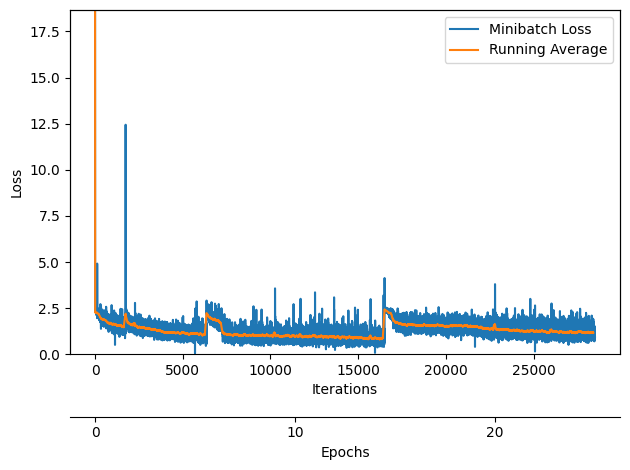

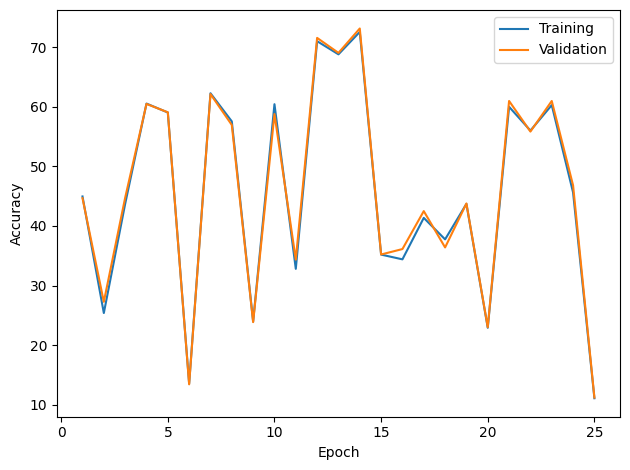

In [ ]:
plot_training_loss(minibatch_loss_list=minibatch_loss_list,
                   num_epochs=NUM_EPOCHS,
                   iter_per_epoch=len(train_loader),
                   results_dir=None,
                   averaging_iterations=100)
plt.show()

plot_accuracy(train_acc_list=train_acc_list,
              valid_acc_list=valid_acc_list,
              results_dir=None)
plt.show()

# **Results - Step 1**

- Train Accuracy = 11.07
- Validation Accuracy = 11.19
- Test Accuracy =11.20

# Step 2


- Activation: ReLU
- Learning Rate: 0.0001
- Optimizer: SGD
- BatchSize: 32
- Epochs: 25




In [ ]:
model = CNN(num_classes=11)

model = model.to(DEVICE)

optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)

minibatch_loss_list, train_acc_list, valid_acc_list = train_model(
    model = model,
    num_epochs = NUM_EPOCHS,
    train_loader = train_loader,
    valid_loader = valid_loader,
    test_loader = test_loader,
    optimizer = optimizer,
    device = DEVICE,
    logging_interval = 50,
    scheduler = None,
    scheduler_on = 'valid_acc'
)


Epoch: 001/025 | Batch 0000/1140 | Loss: 267.3028
Epoch: 001/025 | Batch 0050/1140 | Loss: 2.0060
Epoch: 001/025 | Batch 0100/1140 | Loss: 1.8573
Epoch: 001/025 | Batch 0150/1140 | Loss: 1.8747
Epoch: 001/025 | Batch 0200/1140 | Loss: 1.5788
Epoch: 001/025 | Batch 0250/1140 | Loss: 1.6637
Epoch: 001/025 | Batch 0300/1140 | Loss: 1.9261
Epoch: 001/025 | Batch 0350/1140 | Loss: 1.6980
Epoch: 001/025 | Batch 0400/1140 | Loss: 1.4693
Epoch: 001/025 | Batch 0450/1140 | Loss: 1.4858
Epoch: 001/025 | Batch 0500/1140 | Loss: 1.7330
Epoch: 001/025 | Batch 0550/1140 | Loss: 1.5354
Epoch: 001/025 | Batch 0600/1140 | Loss: 1.6572
Epoch: 001/025 | Batch 0650/1140 | Loss: 1.4360
Epoch: 001/025 | Batch 0700/1140 | Loss: 1.2128
Epoch: 001/025 | Batch 0750/1140 | Loss: 1.1346
Epoch: 001/025 | Batch 0800/1140 | Loss: 1.1301
Epoch: 001/025 | Batch 0850/1140 | Loss: 1.7774
Epoch: 001/025 | Batch 0900/1140 | Loss: 1.7143
Epoch: 001/025 | Batch 0950/1140 | Loss: 1.7377
Epoch: 001/025 | Batch 1000/1140 | Los

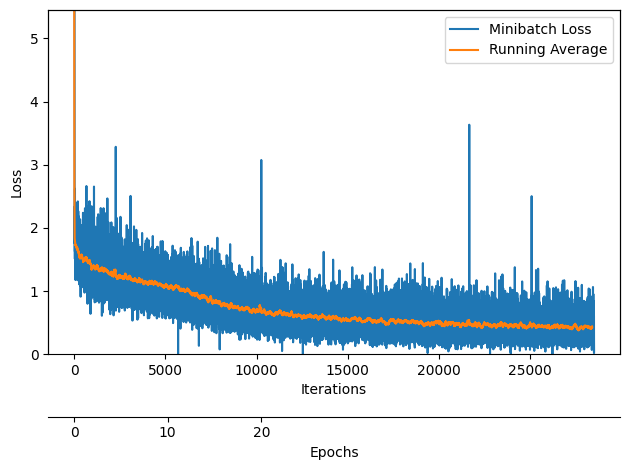

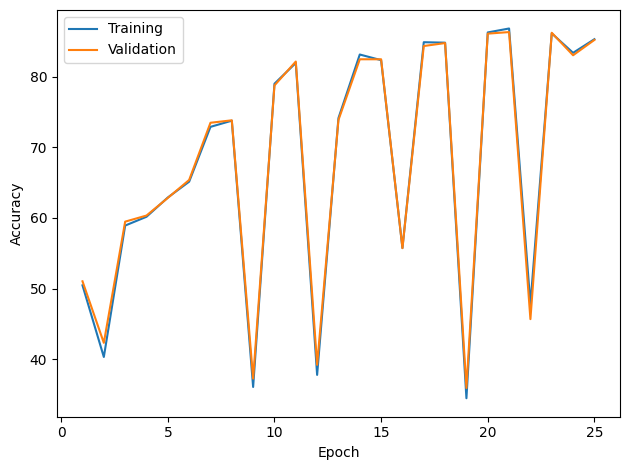

In [ ]:
plot_training_loss(minibatch_loss_list=minibatch_loss_list,
                   num_epochs=NUM_EPOCHS,
                   iter_per_epoch=len(train_loader),
                   results_dir=None,
                   averaging_iterations=100)
plt.show()

plot_accuracy(train_acc_list=train_acc_list,
              valid_acc_list=valid_acc_list,
              results_dir=None)
plt.show()

# **Results - Step 2**

- Train Accuracy = 85.31
- Validation Accuracy = 85.21
- Test Accuracy = 85.69

# **Step 3**



- Activation: ReLU
- Learning Rate: 0.0001
- Optimizer: SGD with momentum 0.9
- BatchSize: 64
- Epochs: 25




In [ ]:
model = CNN(num_classes=11)

model = model.to(DEVICE)

optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

minibatch_loss_list, train_acc_list, valid_acc_list = train_model(
    model = model,
    num_epochs = NUM_EPOCHS,
    train_loader = train_loader,
    valid_loader = valid_loader,
    test_loader = test_loader,
    optimizer = optimizer,
    device = DEVICE,
    logging_interval = 50,
    scheduler = None,
    scheduler_on = 'valid_acc'
)

Epoch: 001/025 | Batch 0000/0513 | Loss: 223.6665
Epoch: 001/025 | Batch 0050/0513 | Loss: 2.0273
Epoch: 001/025 | Batch 0100/0513 | Loss: 1.8087
Epoch: 001/025 | Batch 0150/0513 | Loss: 1.9276
Epoch: 001/025 | Batch 0200/0513 | Loss: 1.5236
Epoch: 001/025 | Batch 0250/0513 | Loss: 1.8401
Epoch: 001/025 | Batch 0300/0513 | Loss: 1.6525
Epoch: 001/025 | Batch 0350/0513 | Loss: 1.4308
Epoch: 001/025 | Batch 0400/0513 | Loss: 1.4682
Epoch: 001/025 | Batch 0450/0513 | Loss: 1.7039
Epoch: 001/025 | Batch 0500/0513 | Loss: 1.5798
Epoch: 001/025 | Train: 50.05% | Validation: 50.56%
Time elapsed: 0.12 min
Epoch: 002/025 | Batch 0000/0513 | Loss: 1.5478
Epoch: 002/025 | Batch 0050/0513 | Loss: 1.1707
Epoch: 002/025 | Batch 0100/0513 | Loss: 1.2713
Epoch: 002/025 | Batch 0150/0513 | Loss: 1.1403
Epoch: 002/025 | Batch 0200/0513 | Loss: 1.4517
Epoch: 002/025 | Batch 0250/0513 | Loss: 1.2725
Epoch: 002/025 | Batch 0300/0513 | Loss: 1.4583
Epoch: 002/025 | Batch 0350/0513 | Loss: 1.3105
Epoch: 002/

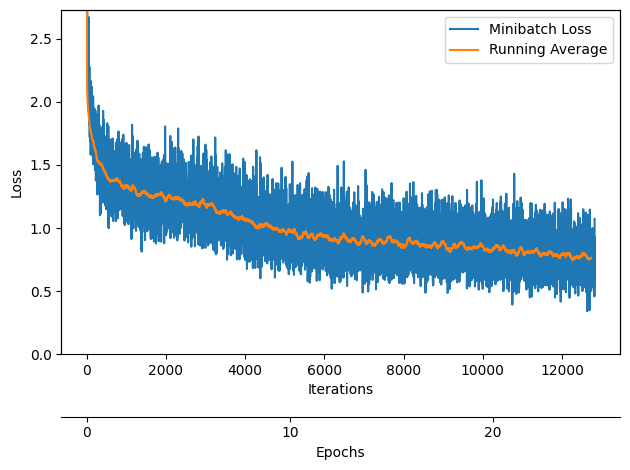

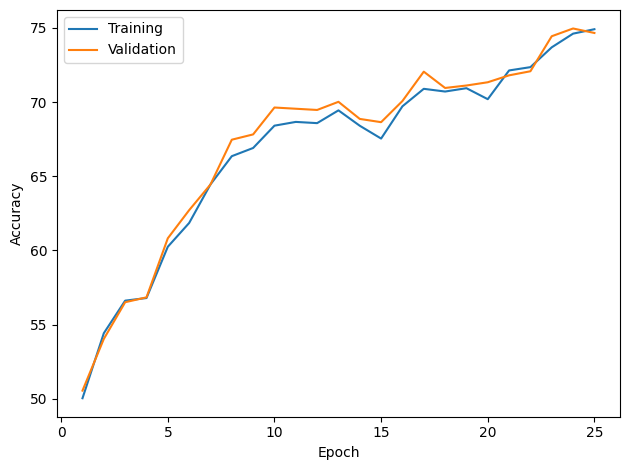

In [ ]:
plot_training_loss(minibatch_loss_list=minibatch_loss_list,
                   num_epochs=NUM_EPOCHS,
                   iter_per_epoch=len(train_loader),
                   results_dir=None,
                   averaging_iterations=100)
plt.show()

plot_accuracy(train_acc_list=train_acc_list,
              valid_acc_list=valid_acc_list,
              results_dir=None)
plt.show()

# **Results - Step 3**

- Train Accuracy = 74.90
- Validation Accuracy = 7465
- Test Accuracy = 75.40

# **Step 4**



- Activation: ReLU
- Learning Rate: 0.001
- Optimizer: Adam
- BatchSize: 32
- Epochs: 25




In [ ]:
model = CNN(num_classes=11)

model = model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

minibatch_loss_list, train_acc_list, valid_acc_list = train_model(
    model = model,
    num_epochs = NUM_EPOCHS,
    train_loader = train_loader,
    valid_loader = valid_loader,
    test_loader = test_loader,
    optimizer = optimizer,
    device = DEVICE,
    logging_interval = 50,
    scheduler = None,
    scheduler_on = 'valid_acc'
)

Epoch: 001/025 | Batch 0000/0923 | Loss: 443.4871
Epoch: 001/025 | Batch 0050/0923 | Loss: 6.9940
Epoch: 001/025 | Batch 0100/0923 | Loss: 3.2458
Epoch: 001/025 | Batch 0150/0923 | Loss: 4.6185
Epoch: 001/025 | Batch 0200/0923 | Loss: 2.9104
Epoch: 001/025 | Batch 0250/0923 | Loss: 3.6950
Epoch: 001/025 | Batch 0300/0923 | Loss: 2.0205
Epoch: 001/025 | Batch 0350/0923 | Loss: 1.3007
Epoch: 001/025 | Batch 0400/0923 | Loss: 2.7843
Epoch: 001/025 | Batch 0450/0923 | Loss: 1.5545
Epoch: 001/025 | Batch 0500/0923 | Loss: 3.5534
Epoch: 001/025 | Batch 0550/0923 | Loss: 1.2000
Epoch: 001/025 | Batch 0600/0923 | Loss: 1.3347
Epoch: 001/025 | Batch 0650/0923 | Loss: 1.4946
Epoch: 001/025 | Batch 0700/0923 | Loss: 0.9372
Epoch: 001/025 | Batch 0750/0923 | Loss: 1.0438
Epoch: 001/025 | Batch 0800/0923 | Loss: 0.9848
Epoch: 001/025 | Batch 0850/0923 | Loss: 1.2855
Epoch: 001/025 | Batch 0900/0923 | Loss: 1.1958
Epoch: 001/025 | Train: 67.00% | Validation: 68.48%
Time elapsed: 0.15 min
Epoch: 002/

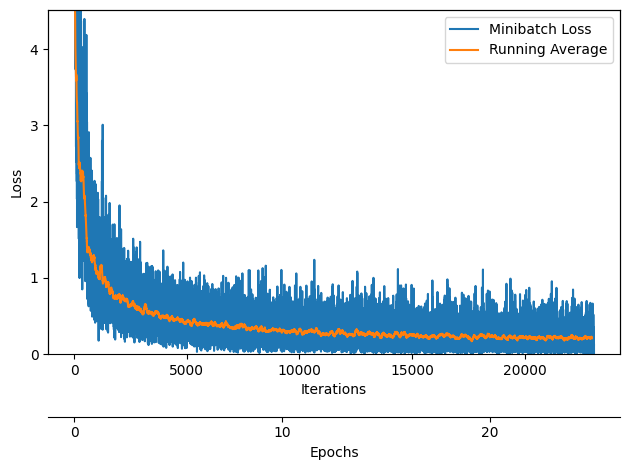

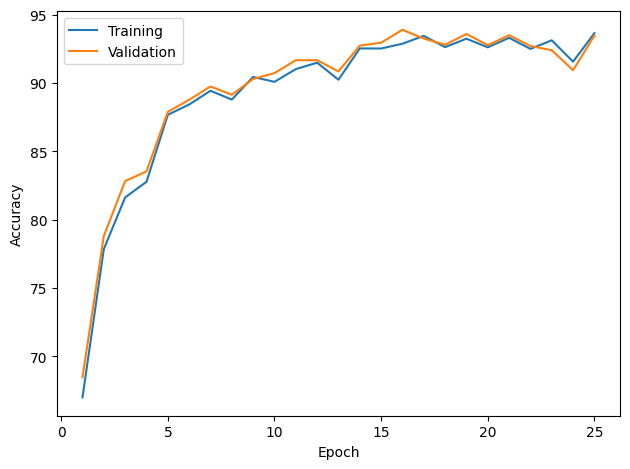

In [ ]:
plot_training_loss(minibatch_loss_list=minibatch_loss_list,
                   num_epochs=NUM_EPOCHS,
                   iter_per_epoch=len(train_loader),
                   results_dir=None,
                   averaging_iterations=100)
plt.show()

plot_accuracy(train_acc_list=train_acc_list,
              valid_acc_list=valid_acc_list,
              results_dir=None)
plt.show()

# **Results - Step 4**

- Train Accuracy = 93.66
- Validation Accuracy = 93.48
- Test Accuracy = 92.96

# **Step 5**

## Step 5: CNN Model with Pre-Activation Batch Normalization

This step introduces **Batch Normalization** layers before the ReLU activation in the convolutional blocks. Batch Normalization helps in stabilizing and accelerating the training of deep neural networks by normalizing the inputs to each layer. This can lead to faster convergence and often allows for higher learning rates.

**Configuration:**




- Activation: ReLU
- Learning Rate: 0.001
- Optimizer: Adam
- BatchSize: 32
- Epochs: 25

Preactivation BatchNorm


In [ ]:
class CNN(torch.nn.Module):
  def __init__(self, num_classes):
    super(CNN, self).__init__()

    self.conv = torch.nn.Sequential(
        torch.nn.Conv1d(8, 32, kernel_size=3, stride=1, padding=1),
        torch.nn.BatchNorm1d(32),
        torch.nn.ReLU(),
        torch.nn.MaxPool1d(kernel_size=2, stride=2),

        torch.nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
        torch.nn.BatchNorm1d(64),
        torch.nn.ReLU(),
        torch.nn.MaxPool1d(kernel_size=2, stride=2),

        torch.nn.AdaptiveAvgPool1d(1),
    )

    self.classifier = torch.nn.Sequential(
        torch.nn.Flatten(),
        torch.nn.Linear(64, 32),
        torch.nn.ReLU(),
        torch.nn.Linear(32, num_classes)
    )

  def forward(self, x):
    x = x.permute(0, 2, 1)  #to convert(batch, seq_len, features) -> (batch, features, seq_len)
    x = self.conv(x)
    x = self.classifier(x)
    return x


In [ ]:
model = CNN(num_classes=11)

model = model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

minibatch_loss_list, train_acc_list, valid_acc_list = train_model(
    model = model,
    num_epochs = NUM_EPOCHS,
    train_loader = train_loader,
    valid_loader = valid_loader,
    test_loader = test_loader,
    optimizer = optimizer,
    device = DEVICE,
    logging_interval = 50,
    scheduler = None,
    scheduler_on = 'valid_acc'
)

Epoch: 001/025 | Batch 0000/1140 | Loss: 2.3965
Epoch: 001/025 | Batch 0050/1140 | Loss: 1.2346
Epoch: 001/025 | Batch 0100/1140 | Loss: 1.4606
Epoch: 001/025 | Batch 0150/1140 | Loss: 1.0235
Epoch: 001/025 | Batch 0200/1140 | Loss: 0.7452
Epoch: 001/025 | Batch 0250/1140 | Loss: 0.8326
Epoch: 001/025 | Batch 0300/1140 | Loss: 0.4564
Epoch: 001/025 | Batch 0350/1140 | Loss: 0.7440
Epoch: 001/025 | Batch 0400/1140 | Loss: 0.4671
Epoch: 001/025 | Batch 0450/1140 | Loss: 0.8571
Epoch: 001/025 | Batch 0500/1140 | Loss: 0.4858
Epoch: 001/025 | Batch 0550/1140 | Loss: 0.6085
Epoch: 001/025 | Batch 0600/1140 | Loss: 0.7975
Epoch: 001/025 | Batch 0650/1140 | Loss: 0.4963
Epoch: 001/025 | Batch 0700/1140 | Loss: 0.1974
Epoch: 001/025 | Batch 0750/1140 | Loss: 0.2892
Epoch: 001/025 | Batch 0800/1140 | Loss: 0.4997
Epoch: 001/025 | Batch 0850/1140 | Loss: 0.6402
Epoch: 001/025 | Batch 0900/1140 | Loss: 0.3681
Epoch: 001/025 | Batch 0950/1140 | Loss: 0.3087
Epoch: 001/025 | Batch 1000/1140 | Loss:

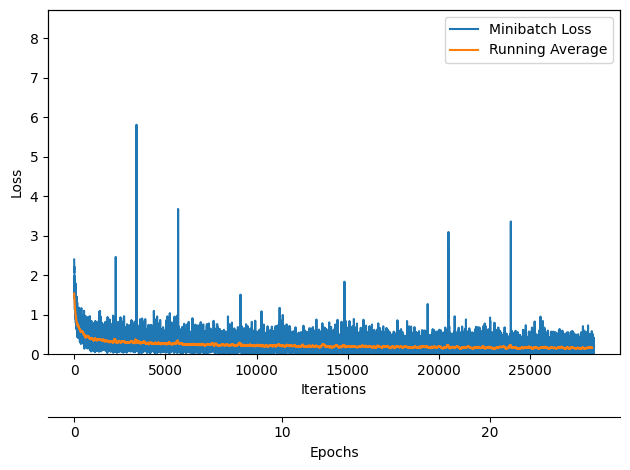

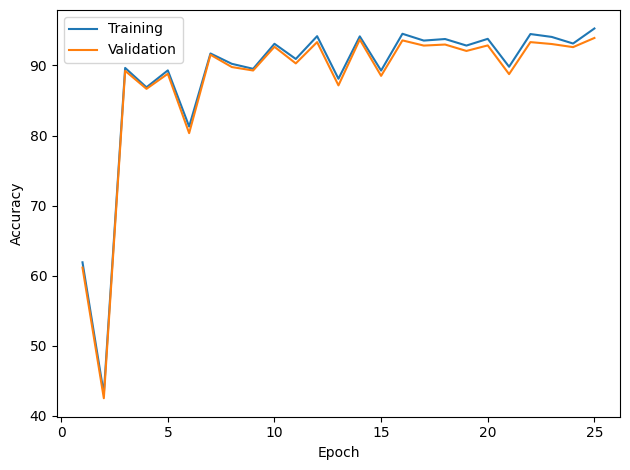

In [ ]:
plot_training_loss(minibatch_loss_list=minibatch_loss_list,
                   num_epochs=NUM_EPOCHS,
                   iter_per_epoch=len(train_loader),
                   results_dir=None,
                   averaging_iterations=100)
plt.show()

plot_accuracy(train_acc_list=train_acc_list,
              valid_acc_list=valid_acc_list,
              results_dir=None)
plt.show()

# **Results - Step 5**

## Results - Step 5

This section summarizes the performance of the model trained with the configuration in Step 5 (Adam optimizer, learning rate 0.001, Batch Normalization). These metrics indicate the model's ability to generalize to unseen data.

- Train Accuracy = 95.28
- Validation Accuracy = 93.93
- Test Accuracy = 94.16

# **Storing the best model**

In [ ]:
torch.save(model, 'cnn_best_model.pt')

from google.colab import files
files.download('cnn_best_model.pt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The trained model (from Step 5, which achieved the highest test accuracy) is saved to a file named `cnn_best_model.pt`. This allows the trained model to be easily reloaded and used later without retraining. The model file is then downloaded to your local machine for persistent storage and future deployment.